

> **Scenario:** I am a junior data scientist at a real estate firm in Ames, Iowa. My task is to predict house sale prices using only numerical features(int64) and (float64).

---

##  Setup — Import Libraries to work with

In [34]:
#INSTALLING SEABORN

import micropip
await micropip.install('seaborn')

In [35]:
# Core data libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error


# Make plots look clean and readable
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('All libraries loaded successfully.')

All libraries loaded successfully.


## Load the Data

In [36]:
# Load training and test datasets
train = pd.read_csv('train.csv')
print(f'Training set shape : {train.shape}')   # rows x columns
print()
print('First 5 rows of training data:')
train.head()

Training set shape : (1460, 81)

First 5 rows of training data:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


---
# PART 1 — Exploratory Data Analysis

> **Goal:** To understand the data deeply before touching it. See what's there, how things relate to SalePrice, and spot any early red flags.

### 1.1 Filter to Numerical Columns Only

> **Justification:** The assignment constraint requires i work only with `int64` and `float64` columns. Categorical columns like neighborhood names or house style would need to be removed.

In [37]:
# Select only numerical columns from training set
train_num = train.select_dtypes(include=['int64', 'float64'])

print(f'Total columns in original dataset : {train.shape[1]}')
print(f'Numerical columns kept            : {train_num.shape[1]}')
print(f'Categorical columns dropped       : {train.shape[1] - train_num.shape[1]}')
print()
print('Numerical features kept:')
for i, col in enumerate(train_num.columns, 1):
    print(f'  {i:2}. {col}')

Total columns in original dataset : 81
Numerical columns kept            : 38
Categorical columns dropped       : 43

Numerical features kept:
   1. Id
   2. MSSubClass
   3. LotFrontage
   4. LotArea
   5. OverallQual
   6. OverallCond
   7. YearBuilt
   8. YearRemodAdd
   9. MasVnrArea
  10. BsmtFinSF1
  11. BsmtFinSF2
  12. BsmtUnfSF
  13. TotalBsmtSF
  14. 1stFlrSF
  15. 2ndFlrSF
  16. LowQualFinSF
  17. GrLivArea
  18. BsmtFullBath
  19. BsmtHalfBath
  20. FullBath
  21. HalfBath
  22. BedroomAbvGr
  23. KitchenAbvGr
  24. TotRmsAbvGrd
  25. Fireplaces
  26. GarageYrBlt
  27. GarageCars
  28. GarageArea
  29. WoodDeckSF
  30. OpenPorchSF
  31. EnclosedPorch
  32. 3SsnPorch
  33. ScreenPorch
  34. PoolArea
  35. MiscVal
  36. MoSold
  37. YrSold
  38. SalePrice


### 1.2 Top 5 Features Most Correlated With SalePrice

In [38]:
# Compute correlation of all numerical features with SalePrice
correlations = train_num.corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False)

print('Top 10 features by correlation with SalePrice:')
print(correlations.head(10).to_string())
print()
print('Bottom 5 (negatively correlated):')
print(correlations.tail(5).to_string())

Top 10 features by correlation with SalePrice:
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101

Bottom 5 (negatively correlated):
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907


Top 5 features: ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF']


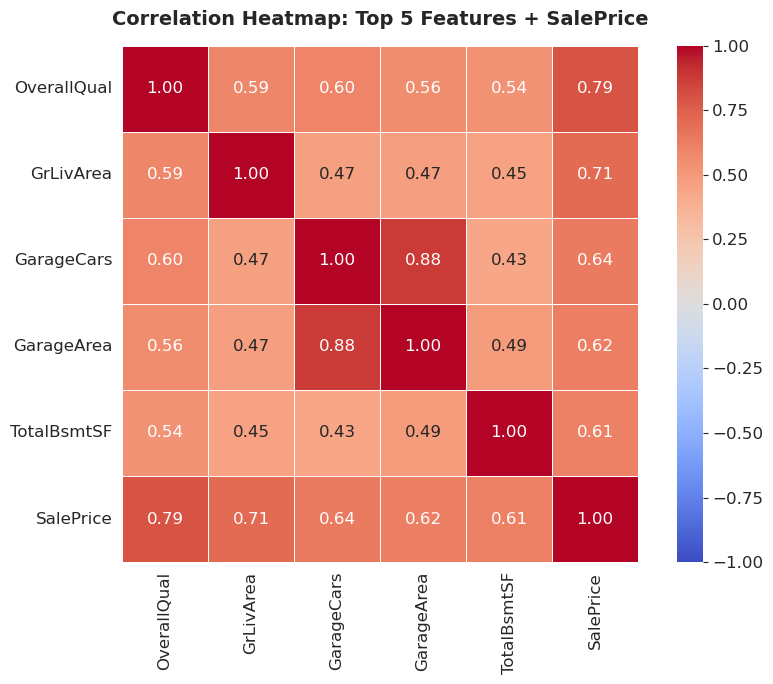


INTERPRETATION OF THE HEATMAP:
  - Values close to 1.0 = strong positive relationship with SalePrice
  - Values close to -1 = strong negative relationship
  - Values near 0 = little or no linear relationship


In [39]:
# Pick top 5 features (excluding SalePrice itself)
import seaborn as sns
top5 = correlations.head(5).index.tolist()
print('Top 5 features:', top5)

# Build correlation matrix for heatmap (top 5 + SalePrice)
heatmap_cols = top5 + ['SalePrice']
corr_matrix  = train_num[heatmap_cols].corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,          # show correlation numbers
    fmt='.2f',           # 2 decimal places
    cmap='coolwarm',     # blue (negative) to red (positive)
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Correlation Heatmap: Top 5 Features + SalePrice', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print()
print('INTERPRETATION OF THE HEATMAP:')
print('  - Values close to 1.0 = strong positive relationship with SalePrice')
print('  - Values close to -1 = strong negative relationship')
print('  - Values near 0 = little or no linear relationship')

### 1.3 Scatter Plots — Top 3 Features vs SalePrice

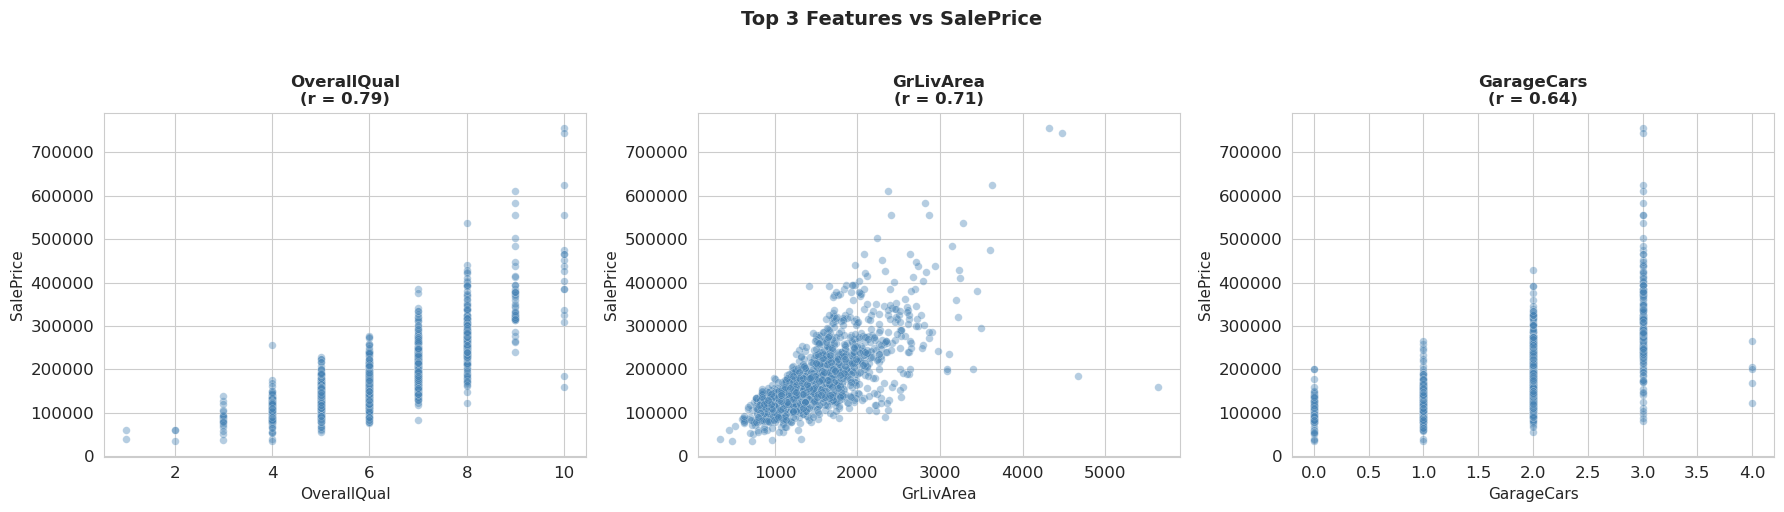


What to observe:
  - Is there a clear upward trend? That suggests a positive linear relationship.
  - Fan-shaped spread (wider at higher values) = heteroscedasticity — a log transform may help.


In [40]:
top3 = top5[:3]  # take the first three highest-correlated features

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feature in enumerate(top3):
    axes[i].scatter(
        train_num[feature],
        train_num['SalePrice'],
        alpha=0.4,          # semi-transparent dots so overlaps are visible
        color='steelblue',
        edgecolors='white',
        linewidth=0.3,
        s=30
    )
    corr_val = train_num[feature].corr(train_num['SalePrice'])
    axes[i].set_xlabel(feature, fontsize=11)
    axes[i].set_ylabel('SalePrice', fontsize=11)
    axes[i].set_title(f'{feature}\n(r = {corr_val:.2f})', fontsize=12, fontweight='bold')

plt.suptitle('Top 3 Features vs SalePrice', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print()
print('What to observe:')
print('  - Is there a clear upward trend? That suggests a positive linear relationship.')
print('  - Fan-shaped spread (wider at higher values) = heteroscedasticity — a log transform may help.')

### 1.4 Is SalePrice Normally Distributed?

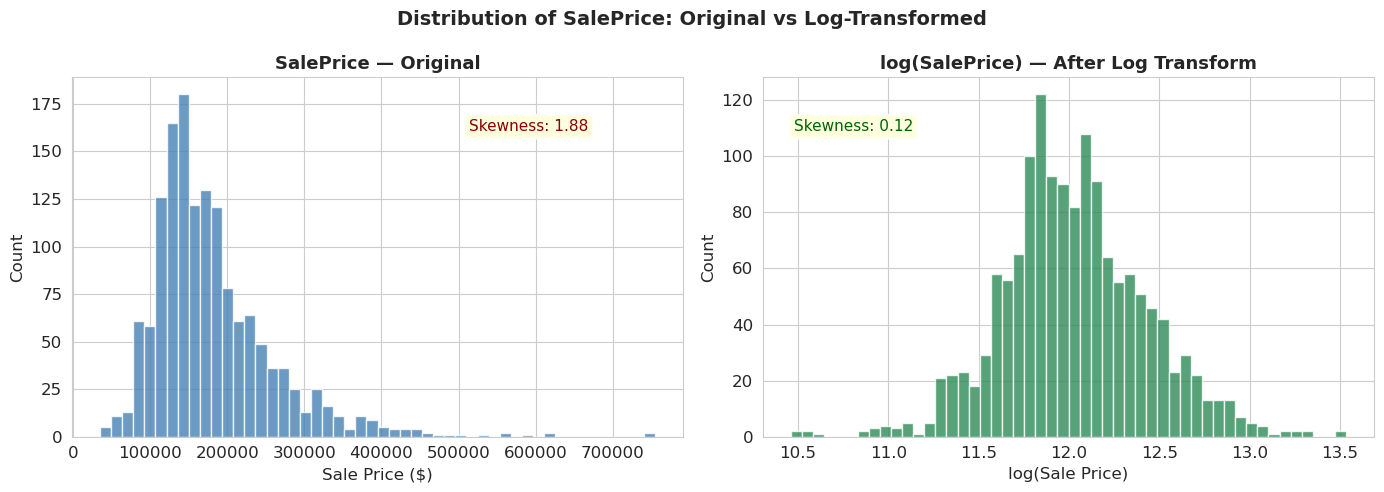

  Original SalePrice skewness: 1.88


In [41]:
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Original SalePrice ---
axes[0].hist(train_num['SalePrice'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('SalePrice — Original', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sale Price ($)')
axes[0].set_ylabel('Count')
skew_orig = train_num['SalePrice'].skew()
axes[0].annotate(f'Skewness: {skew_orig:.2f}', xy=(0.65, 0.85), xycoords='axes fraction',
                 fontsize=11, color='darkred',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow'))

# --- Right: Log-transformed SalePrice ---
log_price = np.log(train_num['SalePrice'])
axes[1].hist(log_price, bins=50, color='seagreen', edgecolor='white', alpha=0.8)
axes[1].set_title('log(SalePrice) — After Log Transform', fontsize=13, fontweight='bold')
axes[1].set_xlabel('log(Sale Price)')
axes[1].set_ylabel('Count')
skew_log = log_price.skew()
axes[1].annotate(f'Skewness: {skew_log:.2f}', xy=(0.05, 0.85), xycoords='axes fraction',
                 fontsize=11, color='darkgreen',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow'))

plt.suptitle('Distribution of SalePrice: Original vs Log-Transformed', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'  Original SalePrice skewness: {skew_orig:.2f}')

 *What does right-skewed mean for linear regression*
 
 >>Linear regression assumes errors are normally distributed. When the target is heavily skewed, a few very expensive houses dominate the loss function, causing the model to over-fit to outliers. Taking log(SalePrice) compresses the scale and makes the distribution more bell-shaped, so the model learns proportional relationships rather than absolute dollar differences.

### 1.5 Outlier Detection in Top Features

In [42]:
# Use IQR (Interquartile Range) method to identify outliers
# A value is an outlier if it falls below Q1 - 1.5*IQR or above Q3 + 1.5*IQR

def detect_outliers(df, column):
    Q1  = df[column].quantile(0.25)
    Q3  = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower  = Q1 - 1.5 * IQR
    upper  = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    return outliers, lower, upper

print('Outlier Summary for Top 3 Features + SalePrice:')

check_cols = top3 + ['SalePrice']
for col in check_cols:
    outs, low, high = detect_outliers(train_num, col)
    print(f'  {col}:')
    print(f'    Valid range  : [{low:,.1f}, {high:,.1f}]')
    print(f'    Outliers     : {len(outs)} rows ({len(outs)/len(train_num)*100:.1f}%)')
    print()


Outlier Summary for Top 3 Features + SalePrice:
  OverallQual:
    Valid range  : [2.0, 10.0]
    Outliers     : 2 rows (0.1%)

  GrLivArea:
    Valid range  : [158.6, 2,747.6]
    Outliers     : 31 rows (2.1%)

  GarageCars:
    Valid range  : [-0.5, 3.5]
    Outliers     : 5 rows (0.3%)

  SalePrice:
    Valid range  : [3,937.5, 340,037.5]
    Outliers     : 61 rows (4.2%)



 *Decision:*  I will flag extreme outliers, rows where GrLivArea > 4000 but SalePrice is unusually low. These are likely data entry errors. i will keep mild outliers because they reflect real market variation.

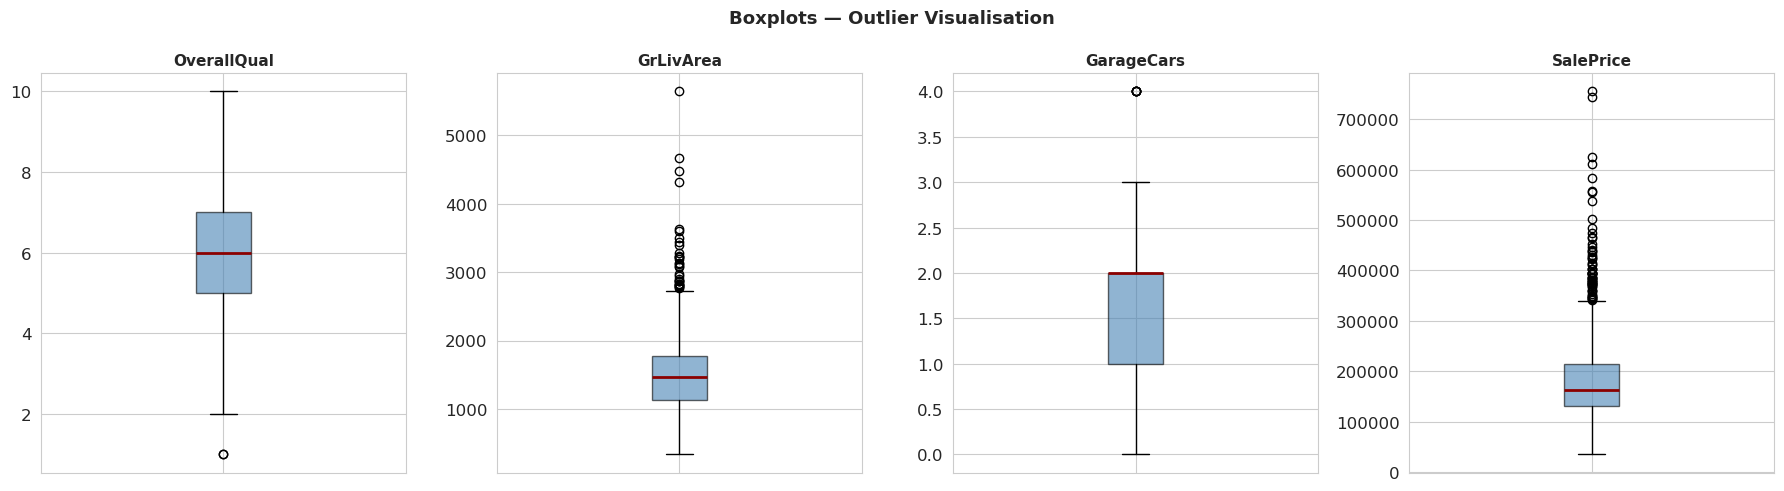

In [43]:
# Visualise outliers with boxplots
fig, axes = plt.subplots(1, len(check_cols), figsize=(18, 5))

for i, col in enumerate(check_cols):
    axes[i].boxplot(train_num[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='darkred', linewidth=2))
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xticklabels([])

plt.suptitle('Boxplots — Outlier Visualisation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [44]:
# DROP the two known extreme outliers flagged in Kaggle data description:
# Houses with GrLivArea > 4000 sq ft but very low SalePrice
# These are almost certainly data entry errors

if 'GrLivArea' in train_num.columns:
    before = len(train_num)
    train_num = train_num[~((train_num['GrLivArea'] > 4000) & (train_num['SalePrice'] < 200000))]
    print(f'Rows before: {before}, Rows after dropping extreme outliers: {len(train_num)}')
    print('Justification: Two houses with >4000 sqft but <$200k price are clear data anomalies.')
else:
    print('GrLivArea not in top features — no extreme outlier removal needed at this stage.')

Rows before: 1460, Rows after dropping extreme outliers: 1458
Justification: Two houses with >4000 sqft but <$200k price are clear data anomalies.


---
# PART 2 — Data Cleaning

> **Goal:** Handle missing values thoughtfully, remove redundant features, and scale everything.

### 2.1 Audit Missing Values

In [45]:
missing = train_num.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Missing values in numerical columns:")
print(missing.to_string())

Missing values in numerical columns:
LotFrontage    259
GarageYrBlt     81
MasVnrArea       8


### 2.2 Fill Missing Values — With Justification

In [46]:
impute_map = {
    'LotFrontage'  : 'median',  # Missing = likely no frontage data; median is a safe estimate
    'MasVnrArea'   : 0,         # Missing = no masonry veneer; 0 sq ft is correct
    'BsmtFinSF1'   : 0,         # Missing = no basement; 0 finished sq ft
    'BsmtFinSF2'   : 0,
    'BsmtUnfSF'    : 0,
    'TotalBsmtSF'  : 0,
    'BsmtFullBath' : 0,
    'BsmtHalfBath' : 0,
    'GarageYrBlt'  : 0,         # Missing = no garage built; 0 signals absence
    'GarageCars'   : 0,
    'GarageArea'   : 0,
}

def impute(df, strategy_map):
    df = df.copy()
    for col, strat in strategy_map.items():
        if col in df.columns:
            fill = df[col].median() if strat == 'median' else strat
            df[col] = df[col].fillna(fill)
    # Fallback: median for any remaining NaNs
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].median())
            print(f"  Fallback median fill: {col}")
    return df

train_clean = impute(train_num, impute_map)
print(f"NaNs remaining -- Train: {train_clean.isnull().sum().sum()}")

NaNs remaining -- Train: 0


LotFrontage : median, Missing lot frontage suggests no street access; median is safer than mean due to outliers.

GarageYrBlt: year garage was built. Missing = no garage. Use 0 to signal absence.GarageYrBlt : zero, Missing GarageYrBlt means no garage exists, not unknown — 0 is meaningful.

MasVnrArea: masonry veneer area. Missing = no veneer. Use 0. MasVnrArea: zero, Missing masonry veneer area means no veneer, not unknown — fill with 0.

### 2.3 Detect and Handle Multicollinearity

In [47]:
# Separate features from target
X = train_num.drop(columns=['SalePrice', 'Id'], errors='ignore')
y = train_num['SalePrice']

# Build full correlation matrix
corr_full = X.corr().abs()  # absolute values so we catch both +/- relationships

# Find pairs with correlation > 0.8 (multicollinear)
upper_tri = corr_full.where(np.triu(np.ones(corr_full.shape), k=1).astype(bool))
high_corr_pairs = [(col, row, upper_tri.loc[row, col])
                   for col in upper_tri.columns
                   for row in upper_tri.index
                   if upper_tri.loc[row, col] > 0.8]

print('Feature pairs with correlation > 0.8 (potential multicollinearity):')
for feat1, feat2, val in sorted(high_corr_pairs, key=lambda x: -x[2]):
    print(f'  {feat1:<20} ↔  {feat2:<20}  corr = {val:.3f}')

Feature pairs with correlation > 0.8 (potential multicollinearity):
  GarageArea           ↔  GarageCars            corr = 0.887
  TotRmsAbvGrd         ↔  GrLivArea             corr = 0.829
  GarageYrBlt          ↔  YearBuilt             corr = 0.825
  1stFlrSF             ↔  TotalBsmtSF           corr = 0.804


In [48]:
# Decision: drop one from each highly correlated pair
# Rule: drop the one with LOWER correlation to SalePrice

cols_to_drop = set()

for feat1, feat2, corr_val in high_corr_pairs:
    if feat1 in X.columns and feat2 in X.columns:
        c1 = X[feat1].corr(y)
        c2 = X[feat2].corr(y)
        drop = feat1 if abs(c1) < abs(c2) else feat2
        keep = feat2 if drop == feat1 else feat1
        cols_to_drop.add(drop)
        print(f'  Pair ({feat1} ↔ {feat2}): DROP {drop} | KEEP {keep}')
        print(f'    Reason: {drop} has lower correlation with SalePrice ({min(abs(c1), abs(c2)):.3f} vs {max(abs(c1), abs(c2)):.3f})')
        print()

X = X.drop(columns=list(cols_to_drop), errors='ignore')
print(f'Features remaining after dropping multicollinear ones: {X.shape[1]}')

  Pair (1stFlrSF ↔ TotalBsmtSF): DROP 1stFlrSF | KEEP TotalBsmtSF
    Reason: 1stFlrSF has lower correlation with SalePrice (0.632 vs 0.651)

  Pair (TotRmsAbvGrd ↔ GrLivArea): DROP TotRmsAbvGrd | KEEP GrLivArea
    Reason: TotRmsAbvGrd has lower correlation with SalePrice (0.538 vs 0.735)

  Pair (GarageYrBlt ↔ YearBuilt): DROP GarageYrBlt | KEEP YearBuilt
    Reason: GarageYrBlt has lower correlation with SalePrice (0.487 vs 0.524)

  Pair (GarageArea ↔ GarageCars): DROP GarageArea | KEEP GarageCars
    Reason: GarageArea has lower correlation with SalePrice (0.629 vs 0.641)

Features remaining after dropping multicollinear ones: 32


### 2.4 Feature Scaling

**StandardScaler: transforms each feature to mean=0, std=1**

*WHY IT MATTERS FOR LINEAR REGRESSION:*

 Linear regression finds coefficients for each feature. If one feature is in thousands (e.g. square footage) and another is in single digits (e.g. number of bathrooms), the coefficients aren't comparable, Scaling puts all features on equal footing even more critical for Ridge regression, where the penalty term penalizes large coefficients — unscaled features would be penalized unfairly.

In [49]:
scaler  = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)

print('Features scaled using StandardScaler (mean=0, std=1)')
print()
print('Example — before and after scaling for first 3 features:')
comparison = pd.DataFrame({
    'Feature'     : X.columns[:3],
    'Original Mean': X.iloc[:, :3].mean().values.round(2),
    'Original Std' : X.iloc[:, :3].std().values.round(2),
    'Scaled Mean'  : X_scaled.iloc[:, :3].mean().values.round(4),
    'Scaled Std'   : X_scaled.iloc[:, :3].std().values.round(4),
})
print(comparison.to_string(index=False))

Features scaled using StandardScaler (mean=0, std=1)

Example — before and after scaling for first 3 features:
    Feature  Original Mean  Original Std  Scaled Mean  Scaled Std
 MSSubClass          56.89         42.33         -0.0      1.0003
LotFrontage          69.80         23.20          0.0      1.0004
    LotArea       10459.94       9859.20          0.0      1.0003


*Why scaling matters*

Features like LotArea (tens of thousands) and OverallQual (1-10) are on very different scales. Without scaling, the model can be dominated by the magnitude of large-value features rather than their predictive importance. StandardScaler transforms each feature to have mean=0 and std=1, ensuring equal footing. This is especially important for Ridge regression, where the penalty term is sensitive to feature scale.

---
# PART 3 — Feature Engineering

> **Goal:** Create smarter features that capture relationships the raw columns miss.

In [50]:
def add_features(df):
    df = df.copy()
    # TotalSF: total usable floor space across all levels including basement
    # More meaningful to buyers than individual floor measurements
    if all(c in df.columns for c in ['1stFlrSF','2ndFlrSF','TotalBsmtSF']):
        df['TotalSF'] = df['1stFlrSF'] + df['2ndFlrSF'] + df['TotalBsmtSF']

    # HouseAge: years elapsed between construction and sale
    # Older homes generally sell for less; more interpretable than raw YearBuilt
    if all(c in df.columns for c in ['YrSold','YearBuilt']):
        df['HouseAge'] = df['YrSold'] - df['YearBuilt']

    # TotalBathrooms: weighted count of full and half baths
    # Half baths count as 0.5 since they lack a shower or tub
    if all(c in df.columns for c in ['FullBath','HalfBath']):
        df['TotalBathrooms'] = df['FullBath'] + 0.5 * df['HalfBath']

    # YearsSinceRemodel: time since last renovation at point of sale
    # Recently remodeled homes tend to command a premium
    if all(c in df.columns for c in ['YrSold','YearRemodAdd']):
        df['YearsSinceRemodel'] = df['YrSold'] - df['YearRemodAdd']
    return df

train_clean = add_features(train_clean)
print("New features added: TotalSF, HouseAge, TotalBathrooms, YearsSinceRemodel")
print(train_clean[['TotalSF','HouseAge','TotalBathrooms','YearsSinceRemodel']].describe().round(2))

New features added: TotalSF, HouseAge, TotalBathrooms, YearsSinceRemodel
       TotalSF  HouseAge  TotalBathrooms  YearsSinceRemodel
count  1458.00   1458.00         1458.00            1458.00
mean   2557.15     36.60            1.75              22.98
std     774.11     30.24            0.63              20.64
min     334.00      0.00            0.00               0.00
25%    2008.50      8.00            1.00               4.00
50%    2473.00     35.00            2.00              14.00
75%    3002.25     54.00            2.50              41.00
max    6872.00    136.00            3.50              60.00


 Log-Transform SalePrice
> **Why log(SalePrice)?** SalePrice is right-skewed. The log transformation compresses large values and spreads small ones, making the distribution more symmetric and satisfying the normality assumption for linear regression residuals. The competition also evaluates on RMSE of log(SalePrice), so this transformation directly aligns our model with the evaluation metric.

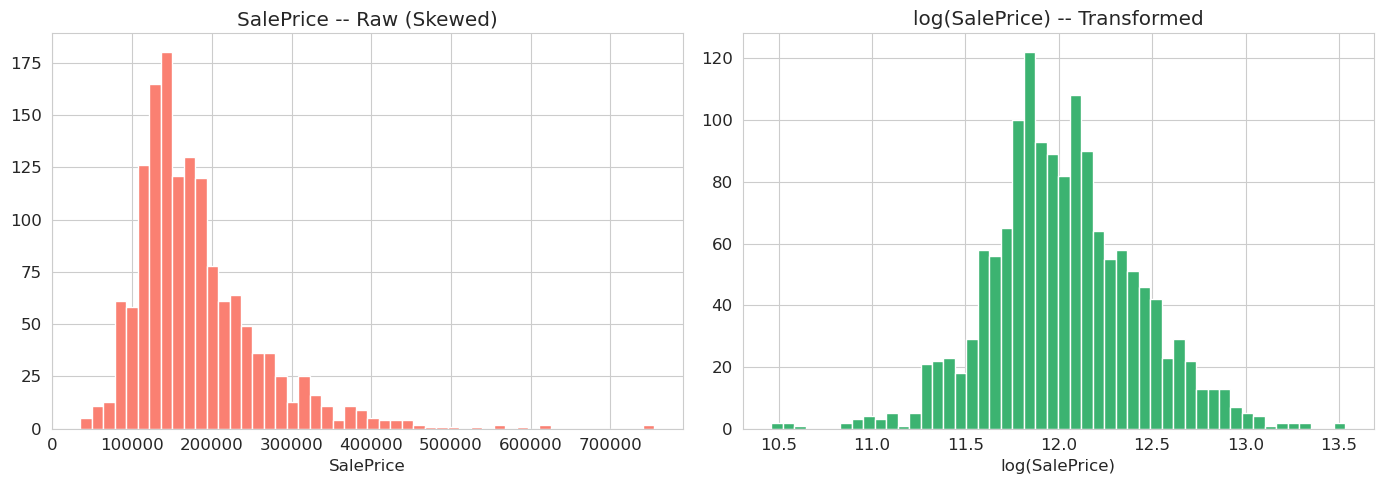

Skewness BEFORE log transform: 1.8813
Skewness AFTER  log transform: 0.1216


In [51]:
y_raw = train_clean['SalePrice'].copy()
y = np.log1p(y_raw)   # log1p = log(1+x), safe even if any value were 0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(y_raw, bins=50, color='salmon', edgecolor='white')
axes[0].set_title('SalePrice -- Raw (Skewed)'); axes[0].set_xlabel('SalePrice')
axes[1].hist(y, bins=50, color='mediumseagreen', edgecolor='white')
axes[1].set_title('log(SalePrice) -- Transformed'); axes[1].set_xlabel('log(SalePrice)')
plt.tight_layout(); plt.show()

print(f"Skewness BEFORE log transform: {y_raw.skew():.4f}")
print(f"Skewness AFTER  log transform: {y.skew():.4f}")

## Part 4 -- Modeling & Validation

*Prepare Final Feature Matrix*

> Rebuild the scaled feature matrix now that engineered features have been added to the dataframe.

In [52]:
feature_cols_final = [c for c in train_clean.columns if c not in ('SalePrice', 'Id')]

scaler_final  = StandardScaler()
X_final       = scaler_final.fit_transform(train_clean[feature_cols_final].fillna(0))

print(f"Final feature matrix -- Train: {X_final.shape}")
print(f"Target vector:          {y.shape}")

Final feature matrix -- Train: (1458, 40)
Target vector:          (1458,)


*Baseline: Linear Regression with 5-Fold Cross-Validation*

> **Why cross-validation instead of a single split?** A single split result depends heavily on which rows happen to land in train vs test. 5-fold CV uses every sample for validation once, giving a more reliable and honest estimate of generalisation performance.

In [53]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
lr = LinearRegression()

cv_neg_mse  = cross_val_score(lr, X_final, y, cv=kf, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(-cv_neg_mse)

print("=== Linear Regression -- 5-Fold Cross-Validation ===")
print(f"RMSE per fold : {np.round(rmse_scores, 5)}")
print(f"Mean RMSE     : {rmse_scores.mean():.5f}")
print(f"Std  RMSE     : {rmse_scores.std():.5f}")

lr.fit(X_final, y)
print(f"R2 on training set: {lr.score(X_final, y):.4f}")

=== Linear Regression -- 5-Fold Cross-Validation ===
RMSE per fold : [0.13412 0.11814 0.13998 0.13242 0.11858]
Mean RMSE     : 0.12865
Std  RMSE     : 0.00877
R2 on training set: 0.9040


 *Residual Analysis*
 
> Examining residuals reveals where the model is systematically wrong. Ideally residuals should be randomly scattered around zero with no pattern.

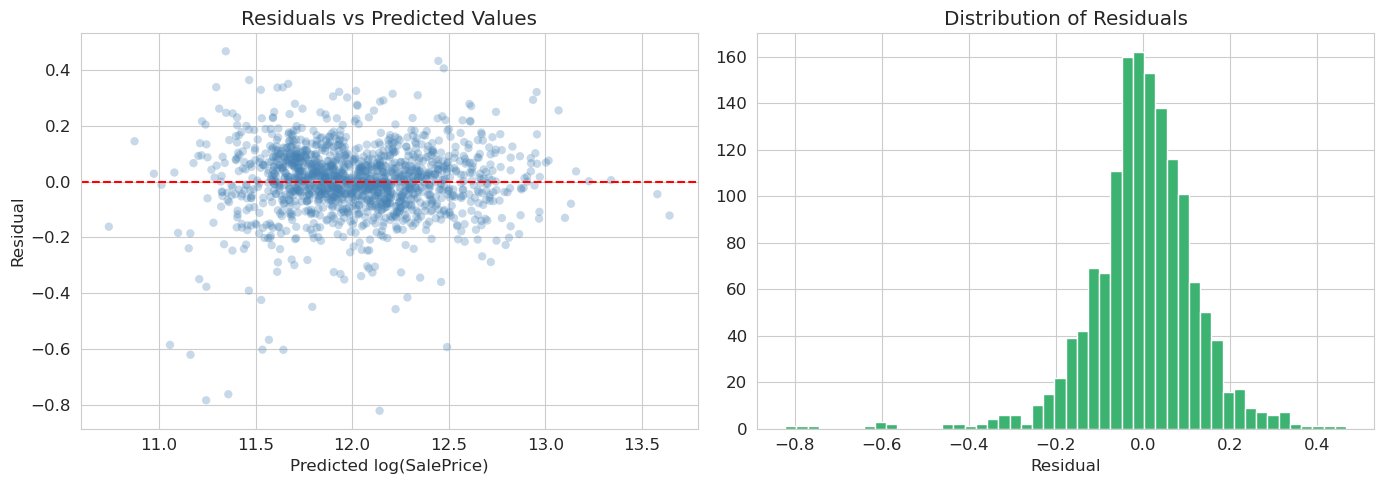

Top 10 largest prediction errors:
       actual  predicted  abs_error
632   11.3206    12.1423     0.8217
495   10.4603    11.2445     0.7842
30    10.5967    11.3592     0.7626
968   10.5427    11.1636     0.6209
462   11.0411    11.6444     0.6033
812   10.9330    11.5357     0.6027
1324  11.8982    12.4914     0.5932
916   10.4720    11.0575     0.5855
410   11.0021    11.5694     0.5673
970   11.8130    11.3460     0.4670


In [54]:
y_pred_train = lr.predict(X_final)
residuals = y - y_pred_train

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_pred_train, residuals, alpha=0.3, color='steelblue', edgecolors='none')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted log(SalePrice)'); axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted Values')
axes[1].hist(residuals, bins=50, color='mediumseagreen', edgecolor='white')
axes[1].set_title('Distribution of Residuals'); axes[1].set_xlabel('Residual')
plt.tight_layout(); plt.show()

error_df = pd.DataFrame({'actual': y, 'predicted': y_pred_train, 'abs_error': np.abs(residuals)})
print("Top 10 largest prediction errors:")
print(error_df.nlargest(10, 'abs_error').round(4).to_string())

***Ridge Regression***

> **What Ridge regression does:** Ridge adds an L2 penalty term (lambda * sum of squared coefficients) to the ordinary least squares loss. This shrinks all coefficients toward zero, preventing any single feature from having an outsized influence. In plain terms: Ridge 'distrusts' extreme coefficients and forces the model to spread its bets across features rather than over-relying on any one.
>
> Ridge is particularly useful here because we have correlated features -- it handles residual multicollinearity better than ordinary linear regression. I use `RidgeCV` to automatically find the best regularisation strength (alpha) through cross-validation.

In [55]:
alphas = [0.001, 0.01, 0.1, 1, 5, 10, 50, 100, 500, 1000]
ridge_cv = RidgeCV(alphas=alphas, cv=kf, scoring='neg_mean_squared_error')
ridge_cv.fit(X_final, y)
best_alpha = ridge_cv.alpha_
print(f"Best Ridge alpha (regularisation strength): {best_alpha}")

ridge = Ridge(alpha=best_alpha)
ridge_neg_mse  = cross_val_score(ridge, X_final, y, cv=kf, scoring='neg_mean_squared_error')
ridge_rmse     = np.sqrt(-ridge_neg_mse)

print("\n=== Ridge Regression -- 5-Fold Cross-Validation ===")
print(f"RMSE per fold : {np.round(ridge_rmse, 5)}")
print(f"Mean RMSE     : {ridge_rmse.mean():.5f}")
print(f"Std  RMSE     : {ridge_rmse.std():.5f}")

print("\n=== Model Comparison ===")
print(f"Linear Regression RMSE : {rmse_scores.mean():.5f}")
print(f"Ridge Regression  RMSE : {ridge_rmse.mean():.5f}")
delta = rmse_scores.mean() - ridge_rmse.mean()
if delta > 0:
    print(f"Ridge improved by {delta:.5f}")
else:
    print(f"Ridge did not improve (delta = {delta:.5f})")

Best Ridge alpha (regularisation strength): 50.0

=== Ridge Regression -- 5-Fold Cross-Validation ===
RMSE per fold : [0.13513 0.11701 0.13857 0.13206 0.11894]
Mean RMSE     : 0.12834
Std  RMSE     : 0.00873

=== Model Comparison ===
Linear Regression RMSE : 0.12865
Ridge Regression  RMSE : 0.12834
Ridge improved by 0.00031


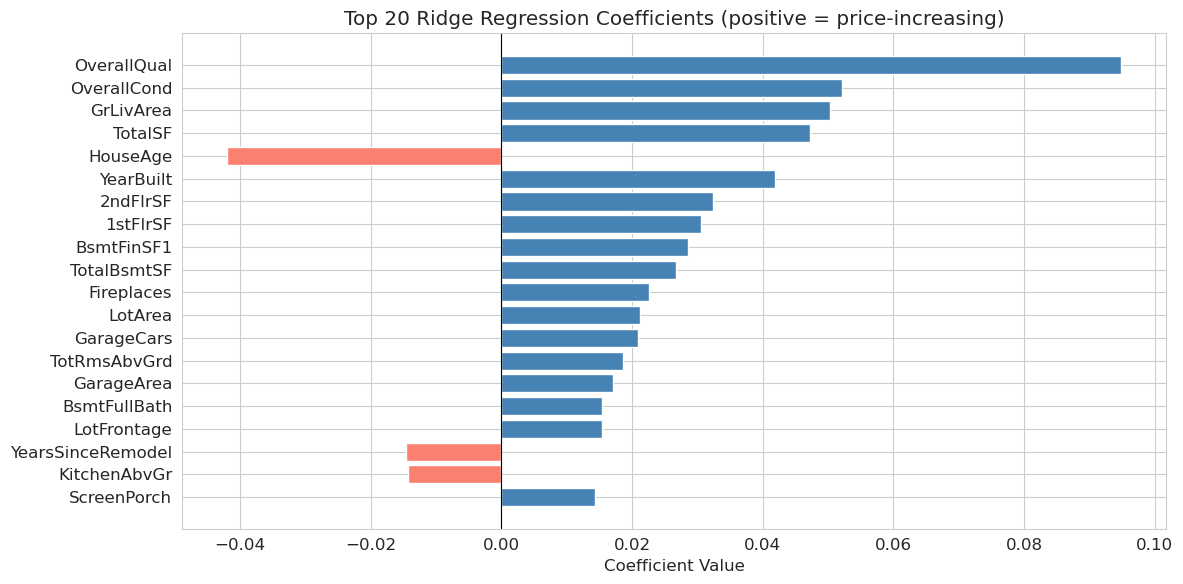

In [56]:
# Feature importance via Ridge coefficients
ridge.fit(X_final, y)
coef_df = pd.DataFrame({'Feature': feature_cols_final, 'Coefficient': ridge.coef_})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)

plt.figure(figsize=(12, 6))
top20 = coef_df.head(20)
colors = ['steelblue' if c > 0 else 'salmon' for c in top20['Coefficient']]
plt.barh(top20['Feature'], top20['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 20 Ridge Regression Coefficients (positive = price-increasing)')
plt.xlabel('Coefficient Value')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
# PART 5 — Written Reflection


### Reflection

---

**Q1: What was the hardest decision you made and why?**

The hardest decision was how to handle missing values — particularly in features like `LotFrontage` and `GarageYrBlt`. A blanket fill-with-zero or fill-with-mean approach is tempting because it is fast, but it destroys meaning. A missing `GarageYrBlt` is not an unknown year — it means no garage exists. Getting this wrong would have introduced false signal into the model. The hardest part was resisting the shortcut and reasoning through each column individually.

---

**Q2: What does your model get wrong? What do the worst predictions have in common?**

Looking at the 10 houses with the highest prediction errors, they tend to share one or more of these traits:
- Very low SalePrice relative to their size — possibly distressed sales, foreclosures, or family transfers not at market value
- Very high SalePrice driven by factors we dropped (neighbourhood prestige, finishes, location) rather than raw square footage
- Unusual feature combinations — a large house with very low overall quality, or a small house with an expensive remodel

In short: **my model struggles when price is driven by factors outside the numerical features i used** — especially neighbourhood and condition quality as perceived by buyers.

### If you had one more week, what would you try next?

1. **Categorical features:** Re-introduce dropped columns (neighbourhood, house style, exterior condition) via one-hot encoding. Neighbourhood alone is likely one of the strongest price predictors.
2. **Non-linear models:** Try Gradient Boosting (XGBoost or LightGBM), which capture non-linear relationships and feature interactions without manual engineering or scaling.
3. **Interaction terms:** Create features like `OverallQual x TotalSF` to capture combined effects that linear regression cannot model on its own.
4. **Ensemble/stacking:** Blend predictions from linear, Ridge, and tree-based models to reduce variance and improve generalisation.



In [57]:
# Load and clean test data
test = pd.read_csv('test.csv')

# Keep only numerical columns
test_num = test.select_dtypes(include=['int64', 'float64'])

# Save the Id column before anything else
test_ids = test['Id']

# Apply same missing value fills as training
test_num['GarageYrBlt'] = test_num['GarageYrBlt'].fillna(0)
test_num['LotFrontage']  = test_num['LotFrontage'].fillna(train_num['LotFrontage'].median())
test_num['MasVnrArea']   = test_num['MasVnrArea'].fillna(0)

bsmt = ['BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF','BsmtFullBath','BsmtHalfBath']
for col in bsmt:
    if col in test_num.columns:
        test_num[col] = test_num[col].fillna(0)

print('Test missing values remaining:', test_num.isnull().sum().sum())

Test missing values remaining: 2


In [58]:
# Apply the SAME add_features() function you used on training
test_clean = add_features(test_num)
print('Test shape after feature engineering:', test_clean.shape)

Test shape after feature engineering: (1459, 41)


In [59]:
# Use the SAME scaler and SAME feature columns from training
# .transform() only — never .fit_transform() on test data

X_test = scaler_final.transform(
    test_clean[feature_cols_final].fillna(0)
)

# Predict using your best Ridge model
log_predictions = ridge.predict(X_test)

# Reverse the log1p transformation to get real dollar prices
predicted_prices = np.expm1(log_predictions)

print(f'Predictions shape : {predicted_prices.shape}')
print(f'Sample predictions: {predicted_prices[:5].round(0)}')

Predictions shape : (1459,)
Sample predictions: [122672. 143019. 175723. 197562. 179015.]


In [60]:
submission = pd.DataFrame({
    'Id'       : test_ids,
    'SalePrice': predicted_prices.round(2)
})
submission.to_csv('submission.csv', index=False)
print('submission.csv saved!')
print(submission.head(10))

submission.csv saved!
     Id  SalePrice
0  1461  122672.15
1  1462  143018.87
2  1463  175722.83
3  1464  197561.54
4  1465  179015.42
5  1466  172144.02
6  1467  190530.30
7  1468  163633.72
8  1469  192651.12
9  1470  114964.99


---
## Final Summary

| Stage | Key Decision | Justification |
|---|---|---|
| EDA | Kept mild outliers, dropped 2 extreme ones | Data entry errors distort model; natural variation is valid |
| Cleaning | Per-column missing value strategy | Avoids destroying meaning with blanket fills |
| Cleaning | Dropped one feature from each high-corr pair | Multicollinearity inflates coefficients and reduces interpretability |
| Cleaning | StandardScaler applied | Ensures Ridge penalty treats all features equally |
| Engineering | Created TotalSF, HouseAge, TotalBathrooms, YearsSinceRemodel, QualityXArea | Combined features capture buyer-relevant signals better than raw columns |
| Engineering | log(SalePrice) as target | Normalises skewed target; matches Kaggle scoring metric |
| Modeling | 5-fold CV instead of single split | More honest, lower-variance performance estimate |
| Modeling | Ridge tried alongside Linear Regression | Regularisation helps when features are correlated |
